In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [3]:
# Pointing the path to the import and parameter files
import sys
sys.path.insert(0, '../../')
# Import list
from imports import *
# Parameter list
import param as pm

In [3]:
## rc parameter files

small = 12
medium = 16
big = 25

plt.rc('font', size=small)          # controls default text sizes
plt.rc('axes', titlesize=big)     # fontsize of the axes title
plt.rc('axes', labelsize=medium)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=small)    # fontsize of the tick labels
plt.rc('ytick', labelsize=small)    # fontsize of the tick labels
plt.rc('legend', fontsize=small)    # legend fontsize
plt.rc('figure', titlesize=big)  # fontsize of the figure title

In [4]:
# Returning the date/time of observation or unix time
fname, dtime=tools.timepoint(fname=pm.file, date=None)


Date of observation: 2019-02-25 02:40:11
Fname: 1551055211


#### Running satellite catalogue

Sat catelogue for the frequency slices of choice

In [5]:
sat_catalogue = '/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/\
Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2.csv'

f_pair = [[1250,1350],[1100,1350],[1150,1305]]

fs_slice, fe_slice = f_pair[2]

In [6]:
def sat_catlog_slice(sat_catalogue, fs_slice, fe_slice):
    df_sc = pd.read_csv(sat_catalogue) 
    
    # Only for using reduced 3 to get reduced 4
    # for i in [12, 13, 21,22,25,26]:
    #     df_sc = df_sc.drop(index=i)
    
    df_sc = df_sc[df_sc["Sys"].str.contains("QZS")==False]

    df_sc.drop((df_sc[df_sc['Frequency[MHz]'] > fe_slice].index), inplace=True)
    df_sc.drop((df_sc[df_sc['Frequency[MHz]'] < fs_slice].index), inplace=True)

    return df_sc


In [ ]:
df_sc = sat_catlog_slice(sat_catalogue=sat_catalogue, fs_slice=1150, fe_slice=1305)

#### ALPHA VALUES

Combining alpha values into a pickle file

In [9]:
# mask_type = ['deg', '_filldeg', 'no']
mask_type = ['deg']

suffix = '_v2_mask_150k_sig1'
alpha_dic = {}
chi_dic = {}
non_count = 0
for mt in mask_type:
    if mt=='no':
        pfile = pickle.load(open(pm.data_save+pm.folder+str(fs_slice)+'_'+str(fe_slice)+'/'+'full_'+mt+'_mask_satellite_f_'+\
                                 str(pm.fs)+'_'+str(pm.fe)+'MHz__'+str(fs_slice)+'_'+str(fe_slice)+'MHz'+suffix+'.p', 'rb'))
        
        alpha_dic.update({mt:pfile['best-fit']})
        chi_dic.update({mt:[pfile['chi2_value'], pfile['chi2_div']]})
        
    else:
        alpha_store = []
        chi_store = []
        for deg_i in range(1,6):
            try:
                pfile = pickle.load(open(pm.data_save+pm.folder+str(fs_slice)+'_'+\
                                                    str(fe_slice)+'/'+'full_'+str(deg_i)+mt+'_mask_satellite_f_'+str(pm.fs)+'_'+str(pm.fe)+'MHz__'+\
                                                    str(fs_slice)+'_'+str(fe_slice)+'MHz'+suffix+'.p', 'rb'))
                alpha_store.append(pfile['best-fit'])
                chi_store.append([pfile['chi2_value'], pfile['chi2_div']])
            
            except FileNotFoundError:
                print ('No '+str(deg_i)+mt+' file available')
                non_count+=1
                continue
        alpha_dic.update({mt:alpha_store})
        chi_dic.update({mt:chi_store})

No 2deg file available
No 3deg file available
No 4deg file available
No 5deg file available


In [10]:

alpha_dic = {}
non_count = 0
for mt in mask_type:
    if mt=='no':
        alpha = pickle.load(open(pm.data_save+pm.folder+str(fs_slice)+'_'+str(fe_slice)+'/'+'full_'+mt+'_mask_satellite_f_'+\
                                 str(pm.fs)+'_'+str(pm.fe)+'MHz__'+str(fs_slice)+'_'+str(fe_slice)+'MHz'+suffix+'.p', 'rb'))['best-fit']
        alpha_dic.update({mt:alpha})
    else:
        alpha_store = []
        for deg_i in range(1,6):
            try:
                alpha_store.append(pickle.load(open(pm.data_save+pm.folder+str(fs_slice)+'_'+\
                                                    str(fe_slice)+'/'+'full_'+str(deg_i)+mt+'_mask_satellite_f_'+str(pm.fs)+'_'+str(pm.fe)+'MHz__'+\
                                                    str(fs_slice)+'_'+str(fe_slice)+'MHz'+suffix+'.p', 'rb'))['best-fit'])
            except FileNotFoundError:
                print ('No '+str(deg_i)+mt+' file available')
                non_count+=1
                continue
        alpha_dic.update({mt:alpha_store})
            
            

No 2deg file available
No 3deg file available
No 4deg file available
No 5deg file available


In [11]:
col_alpha = df_sc.index.values

col_alpha_names = [r'$\alpha_{'+str(x)+'}$' for x in col_alpha]
col_chi_names = [r'$\chi^{2}$', '$\chi^{2}/N$']


# idx_value = np.array(['No mask'])

# df1_alpha = pd.DataFrame(data = np.round(alpha_dic['no'],3), 
#                   index = col_alpha_names, 
#                   columns = idx_value).T

# df1_chi  = pd.DataFrame(data = np.round(chi_dic['no'],3), 
#                   index = col_chi_names, 
#                   columns = idx_value).T

degree_values = [1]

dmd_idx_name_a = np.array(['M-D: '+str(degree_values[x]) for x in range(len(alpha_dic['deg']))])
# dmfd_idx_name_a = np.array(['MF-D: '+str(degree_values[x]) for x in range(len(alpha_dic['_filldeg']))])

df2_alpha = pd.DataFrame(data = np.round(alpha_dic['deg'],3), 
                  index = dmd_idx_name_a, 
                  columns = col_alpha_names )

# df3_alpha = pd.DataFrame(data = np.round(alpha_dic['_filldeg'],3), 
#                   index = dmfd_idx_name_a, 
#                   columns = col_alpha_names )

# df4_alpha = df1_alpha.append(df2_alpha.append(df3_alpha))
df4_alpha = df2_alpha 


dmd_idx_name_c = np.array(['M-D: '+str(degree_values[x]) for x in range(len(chi_dic['deg']))])
# dmfd_idx_name_c = np.array(['MF-D: '+str(degree_values[x]) for x in range(len(chi_dic['_filldeg']))])

df2_chi = pd.DataFrame(data = np.round(chi_dic['deg'],3), 
                  index = dmd_idx_name_c, 
                  columns = col_chi_names )

# df3_chi = pd.DataFrame(data = np.round(chi_dic['_filldeg'],3), 
#                   index = dmfd_idx_name_c, 
#                   columns = col_chi_names )

# df4_chi = df1_chi.append(df2_chi.append(df3_chi))
df4_chi = df2_chi



In [12]:
df4_alpha.to_pickle(path=pm.data_save+pm.folder+'alpha_parameters/alparam_'+str(fs_slice)+'_'+str(fe_slice)+'MHz'+suffix+'.p')
df4_chi.to_pickle(path=pm.data_save+pm.folder+'chi_values/chivalues_'+str(fs_slice)+'_'+str(fe_slice)+'MHz'+suffix+'.p')

In [13]:
stop

NameError: name 'stop' is not defined

#### Testing dataframe alpha values

In [19]:
apath = pm.data_save+pm.folder+'alpha_parameters/alparam_'+str(fs_slice)+'_'+str(fe_slice)+'MHz'
chipath = pm.data_save+pm.folder+'chi_values/chivalues_'+str(fs_slice)+'_'+str(fe_slice)+'MHz'

In [20]:
# Can control who you want to see here
# suf_list = ['_v2_new_version', '_v2_sig1', '_v2_avg20', '_v2_sig1_avg20', '_v2_mask_340k']

suf_list_sig1 = ['_v2_sig1', '_v2_mask_100k_sig1', '_v2_mask_150k_sig1', '_v2_mask_200k_sig1', '_v2_mask_340k_sig1']
suf_list_sigd = ['_v2_new_version', '_v2_mask_100k', '_v2_mask_150k', '_v2_mask_200k', '_v2_mask_340k']


legend_name = ['No mask', '100 Kelvin', '150 Kelvin', '200 Kelvin', '340 Kelvin',]



sat_cat_suffix = ['2']#, '2', '2', '2', '2']


# MASK TYPE
# mask_type = ['M-D: 5', 'MF-D: 5', 'No mask']
# mask_type_name = [r'5 Degree', r'5F Degreee', 'No mask']
# degree_type = ['5', '5_fill', '1']
# #Getting the sizes of the ORIGINAL MASK for all types
# mask_on = [True, True, False]
# timer_on = [False, False, False]
# # suf_list = ['_v2_new_version']

mask_type = ['M-D: 1', 'MF-D: 1', 'M-D: 5', 'MF-D: 5', 'No mask']
mask_type_name = [r'1 Degree', r'1F Degree', r'5 Degree', r'5F Degreee', 'No mask']
degree_type = ['1', '1_fill', '5', '5_fill', '1']
# Getting the sizes of the ORIGINAL MASK for all types
mask_on = [True, True, True, True, False]
timer_on = [False, False, False, False, False]


In [21]:
df_a_list = []     # Alpha dataframe
df_chi_list = []   # Chi square value dataframe
df_sact_cat = []   # Satellite catalogue


for si, suf_name in enumerate(suf_list_sig1):
    df_a_list.append(pd.read_pickle(apath+suf_name+'.p'))
    df_chi_list.append(pd.read_pickle(chipath+suf_name+'.p'))

    sat_cat = '/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_'+sat_cat_suffix[0]+'.csv'

    df_sact_cat.append(sat_catlog_slice(sat_catalogue=sat_cat, fs_slice=1150, fe_slice=1305))

# REMOVAL OF SIGNALS
# ## Need to remove some signals for the fourth
# for di in [12, 13, 21,22,25,26]:
#     df_sact_cat[3] = df_sact_cat[3].drop(index=di)
    
# sat_cat_suffix = ['2', '2', '2', '2', '2']

# CHI N LENGTH
chi_N = len(df_chi_list)

In [22]:
# fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=1, sharey=True)
# ax=axs
# for i in range(chi_N):
#     ax.plot(df_chi_list[i].index, np.log10(df_chi_list[i]['$\chi^{2}$'].values), 'o', label=legend_name[i])
# ax.set_title(r'$\chi^{2}$')
# ax.set_ylabel('Log scale [Best fit]')
# ax.set_xlabel('Mask type')
# ax.legend()
# fig.tight_layout()
# # plt.savefig(pm.data_plot+'fitting/chi_square_'+str(f_pair[2][0])+'_'+str(f_pair[2][1])+'MHz_compare.pdf', bbox_inches='tight')


In [23]:
# fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=1, sharey=True)
# ax=axs
# for i in range(chi_N):
#     ax.plot(df_chi_list[i].index, np.log10(df_chi_list[i]['$\chi^{2}/N$'].values), 'o', label='T:'+suf_list[i])
# ax.set_title(r'$\chi^{2}/N$')
# ax.set_ylabel('Log scale [Best fit]')
# ax.set_xlabel('Mask type')
# ax.legend()
# fig.tight_layout()
# # plt.savefig(pm.data_plot+'fitting/chi_squareN_'+str(f_pair[2][0])+'_'+str(f_pair[2][1])+'MHz_compare.pdf', bbox_inches='tight')


##### Alpha for different catalogs for each mask type

In [24]:
# fig, axs = plt.subplots(figsize=(20, 12), nrows=4, ncols=2, sharey=True)
# for r_plot in range(4):
#     for c_plot in range(2):
#         ax=axs[r_plot, c_plot]
#         if 2*r_plot+c_plot>6:
#             fig.delaxes(ax)
#         else:
#             for i in range(len(mask_type)):
#                 try:
#                     xlist = df_a_list[2*r_plot+c_plot].columns
#                     ylist = df_a_list[2*r_plot+c_plot].loc[df_a_list[2*r_plot+c_plot].index == mask_type[i]].values[0]
#                     ax.plot(xlist, ylist, 'o', label='Type:'+mask_type[i])


#                     ax.set_title(suf_list[2*r_plot+c_plot])
#                     ax.set_xlabel(r'$\alpha$ parameters')
#                     ax.set_ylabel(r'Amplitude value')
#                     handles, labels = ax.get_legend_handles_labels()
#                 except IndexError:
#                     continue

# fig.legend(handles, labels, loc='lower right', bbox_to_anchor=[0.8, 0.1])
# fig.tight_layout()
# # plt.savefig(pm.data_plot+'fitting/alpha_parameters_per_catalog_'+str(f_pair[2][0])+'_'+str(f_pair[2][1])+'MHz_compare.pdf', bbox_inches='tight')


In [25]:
# fig, axs = plt.subplots(figsize=(20, 10), nrows=3, ncols=2, sharey=True)
# fig.suptitle(r'$\alpha$ Parameter constants')
# for r_plot in range(3):
#     for c_plot in range(2):
#         ax=axs[r_plot, c_plot]
#         if 2*r_plot+c_plot>4:
#             fig.delaxes(ax)
#         else:
#             for i in range(len(df_a_list)):
#                 xlist = df_a_list[i].columns
#                 try:
#                     ylist = df_a_list[i].loc[df_a_list[i].index == mask_type[2*r_plot+c_plot]].values[0] 
#                 except IndexError:
#                     continue
#                 ax.set_title(mask_type[2*r_plot+c_plot])

#                 ax.set_xlabel(r'$\alpha$ parameters')
#                 ax.set_ylabel(r'Amplitude value')
#                 ax.plot(xlist, ylist, 'o', label='Type:'+suf_list[i])

#                 handles, labels = ax.get_legend_handles_labels()

# fig.legend(handles, labels, loc='lower right', bbox_to_anchor=[0.8, 0.05])
# fig.tight_layout()
# # plt.savefig(pm.data_plot+'fitting/alpha_parameters_per_mask_'+str(f_pair[2][0])+'_'+str(f_pair[2][1])+'MHz_compare.pdf', bbox_inches='tight')


In [26]:
# fig, axs = plt.subplots(figsize=(20, 10), nrows=3, ncols=2, sharey=True)
# fig.suptitle('Satellite Signal Power')
# for r_plot in range(3):
#     for c_plot in range(2):
#         ax=axs[r_plot, c_plot]
#         if 2*r_plot+c_plot>4:
#             fig.delaxes(ax)
#         else:
#             for i in range(len(df_a_list)):
#                 xlist = df_a_list[i].columns

#                 power = 10**((df_sact_cat[i]['P_t (dBW)'].values+df_sact_cat[i]['G_t (dBi)'].values)/10)
#                 ylist = df_a_list[i].loc[df_a_list[i].index == mask_type[2*r_plot+c_plot]].values[0] * power
#                 ax.set_title(mask_type[2*r_plot+c_plot])

#                 ax.set_xlabel(r'$\alpha$ parameters')
#                 ax.set_ylabel(r'pwr = $P_{t} \times G_{t} \times \alpha$')
#                 ax.plot(xlist, ylist, 'o', label='Type:'+suf_list[i])

#                 handles, labels = ax.get_legend_handles_labels()

# fig.legend(handles, labels, loc='lower right', bbox_to_anchor=[0.8, 0.05])
# fig.tight_layout()
# fig.show()
# # plt.savefig(pm.data_plot+'fitting/satelite_signal_power_'+str(f_pair[2][0])+'_'+str(f_pair[2][1])+'MHz_compare.pdf', bbox_inches='tight')


#### Working from the save data files converting to a panda dataframe

In [27]:
# alpha_fv = []
# for f in f_pair:
#     alpha_v = []
#     version = ['', '_sig1']
#     for v in version:
#         alpha_v.append(pickle.load(open(pm.data_save+pm.folder+'alpha_parameters/alparam_'+str(f[0])+'_'+str(f[1])+'MHz'+v+'.p', 'rb')))
#     alpha_fv.append(alpha_v)

In [28]:
# df0 = alpha_fv[0][0] - alpha_fv[0][1]
# df1 = alpha_fv[1][0] - alpha_fv[1][1]
# df2 = alpha_fv[2][0] - alpha_fv[2][1]

In [29]:
# for ii in range(len(f_pair)):
#     df = alpha_fv[ii][0] - alpha_fv[ii][1]
    
#     fig, axs = plt.subplots(figsize=(21, 3), nrows=1, ncols=3, sharey=True)
#     fig.suptitle(r'$\nu:$['+str(f_pair[ii][0])+'-'+str(f_pair[ii][1])+']MHz: $\sigma_D - \sigma_1$', size=14)

#     ax=axs[0]
#     ax.plot(df.iloc[[0]].values[0])
#     ax.set_xticks((np.arange(len(df.iloc[[0]].values[0]))))
#     ax.set_xticklabels(df.columns)
#     ax.set_title('No mask')
#     ax.set_xlabel('Alpha no.')
#     ax.set_ylabel('Amplitude')

#     ax=axs[1]
#     for n,i in enumerate(df.iloc[1:6].values):
#         ax.plot(i, label='Degree: '+str(n+1))
#     ax.set_xticks((np.arange(len(df.iloc[[0]].values[0]))))
#     ax.set_xticklabels(df.columns)
#     ax.set_title('Masked')
#     ax.legend(ncol=3, loc="lower left")
#     ax.set_xlabel('Alpha no.')

#     ax=axs[2]
#     for n,i in enumerate(df.iloc[6:].values):
#         ax.plot(i, label='Degree: '+str(n+1))
#     ax.set_title('Masked-Filled in')
#     ax.set_xticks((np.arange(len(df.iloc[[0]].values[0]))))
#     ax.set_xticklabels(df.columns)
#     ax.legend(ncol=3, loc="lower left")
#     ax.set_xlabel('Alpha no.')
#     plt.tight_layout()
#     # plt.savefig(pm.data_plot+'fitting/alpha_parameters_'+str(f_pair[ii][0])+'_'+str(f_pair[ii][1])+'MHz_diff_sig1.pdf', bbox_inches='tight')
#     plt.show()

In [30]:
# fig, axs = plt.subplots(figsize=(21, 3), nrows=1, ncols=3, sharey=True)
# fig.suptitle(r'$\nu:$['+str(fs_slice)+'-'+str(fe_slice)+']MHz: Alpha constants', size=14)

# ax=axs[0]
# ax.plot(alpha_dic['no'])
# ax.set_xticks((np.arange(len(alpha_dic['no']))))
# ax.set_xticklabels((np.arange(1, len(alpha_dic['no'])+1)))
# ax.set_title('No mask')
# ax.set_xlabel('Alpha no.')
# ax.set_ylabel('Amplitude')

# ax=axs[1]
# for n,i in enumerate(alpha_dic['deg']):
#     ax.plot(i, label='Degree: '+str(n+1))
# ax.set_xticks((np.arange(len(alpha_dic['no']))))
# ax.set_xticklabels((np.arange(1, len(alpha_dic['no'])+1)))
# ax.set_title('Masked')
# ax.legend()
# ax.set_xlabel('Alpha no.')

# ax=axs[2]
# for n,i in enumerate(alpha_dic['_filldeg']):
#     ax.plot(i, label='Degree: '+str(n+1))
# ax.set_title('Masked-Filled in')
# ax.set_xticks((np.arange(len(alpha_dic['no']))))
# ax.set_xticklabels((np.arange(1, len(alpha_dic['no'])+1)))
# ax.legend()
# ax.set_xlabel('Alpha no.')
# plt.tight_layout()
# # plt.savefig(pm.data_plot+'fitting/alpha_parameters_'+str(fs_slice)+'_'+str(fe_slice)+'MHz_sig1.pdf', bbox_inches='tight')
# plt.show()

#### Running the best fit parameters

In [31]:
fs_slice,fe_slice=f_pair[2]
print ('Running for frequency range: '+str(fs_slice)+'-'+str(fe_slice)+' MHz')
# alp_df = alpha_fv[2][0]
# alp_no = alp_df.loc[alp_df.index == 'No mask'].values[0]


Running for frequency range: 1150-1305 MHz


In [32]:
def satellite_excecute(alpha, degree, sat_cat_suffix, satsonly=None, mask=False, k_mask=None, timer=False):
    '''
    alpha - fitting parameters from best fit
    degree - masking level
    sat_cat_suffix - the ending of the satellite catalog
    mask  - switched on or not
    k_mask - masking kelvin threshold levels
    timer - if the waterfall needs to be time averaged
    '''
    sat_cat = '/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_'+sat_cat_suffix+'.csv'

    sat_full = ss(file_name=fname,          
                 sats_only=satsonly, 
                 data_loc=pm.data_save, 
                 sat_loc=pm.data_save,
                 survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
                 sat_info=sat_cat,
                 plots_loc=pm.data_plot,
                 sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
                 frequency_range=[pm.fs,pm.fe], 
                 constellations=pm.constellations_remain,
                 nearby_satellites=pm.data_save+'nearby_satellites/nearby_satellite_close_angle_'+str(degree)+'.p',
                 verbose=False)


    sat_full.excecute(a_param=alpha,
                     obs_time_start=pm.nd_s0[0], obs_time_end=pm.nd_s0[-1], 
                     obs_frequency_start=fs_slice, obs_frequency_end=fe_slice, 
                     file_bias_choice=pm.bias, 
                     add_sub=[1, 1], 
                     band_lvl=[None, None], 
                     bandsize=None,
                     verbose=True)
    
# MASKING SECTION   
    if mask==True:
        # MASKING DEGREE STRIPS
        full_cds = np.ma.array(data=sat_full.calibration_data_slice.T, mask=sat_full.mask_nearby_satellites_slice)  #DATA
        full_sts = np.ma.array(data=sat_full.simulation_TOD_slice.T, mask=sat_full.mask_nearby_satellites_slice)    #SIMULATIONS

    elif k_mask!=None:
        # MASKING THE THRESHOLD VALUES
        zero_arr = np.zeros(sat_full.calibration_data_slice.shape)
        mask_idx = np.where(sat_full.calibration_data_slice > k_mask)

        zero_arr[mask_idx]=1
        full_sts = np.ma.array(data=sat_full.simulation_TOD_slice.T, mask=zero_arr.T)    #SIMULATIONS
        full_cds = np.ma.array(data=sat_full.calibration_data_slice.T, mask=zero_arr.T)  #DATA

    else:
        #NON-MASK
        full_cds = sat_full.calibration_data_slice.T   #DATA
        full_sts = sat_full.simulation_TOD_slice.T     #SIMULATION

# AVERAGING SECTION  
    if timer==True:
        # TIME AVERAGING
        full_cds = tools.waterfall_avg_time(timer=pm.nd_s0, size=20, waterfall=full_cds)
        full_sts = tools.waterfall_avg_time(timer=pm.nd_s0, size=20, waterfall=full_sts)
    
        

    #FREQUENCY SLICE
    frange_slice = sat_full.frequency_band[sat_full.frequency_idx[0]:sat_full.frequency_idx[1]]  
    
    #TIME SLICE
    ts_slice = sat_full.nd_s0[sat_full.time_idx[0]]   # Starting time
    te_slice = sat_full.nd_s0[sat_full.time_idx[1]-1]   # Ending  time
    
    size = [full_cds.size, full_cds.size - np.sum(full_cds.mask*1)]

    return full_cds, full_sts, frange_slice, size

### Masking idx

In [33]:
def masking_idx(degree, fill=False):
    '''
    Masking indices of the different degrees
    '''
    if fill==True:
        x='_fill'
    else:
        x=''
    mask_path = '/idia/projects/hi_im/brandon/meerkat_gain_cali/1551055211/nearby_satellites/nearby_satellite_close_angle_'+str(degree)+x+'.p'
    d = pickle.load(open(mask_path, 'rb'), encoding='latin1')    
    mask_idx = np.sort(np.concatenate([d[key] for key in d.keys() if len(d[key])>0]))

    
    return mask_idx

midx = masking_idx(degree=1)

#### Original data mask

In [34]:
mask_type = ['M-D: 1', 'MF-D: 1', 'M-D: 5', 'MF-D: 5', 'No mask']
mask_type_name = [r'1 Degree', r'1F Degree', r'5 Degree', r'5F Degreee', 'No mask']
degree_type = ['1', '1_fill', '5', '5_fill', '1']
# Getting the sizes of the ORIGINAL MASK for all types
mask_on = [True, True, True, True, False]
timer_on = [False, False, False, False, False]
suf_list = ['_v2_new_version']

In [35]:
sat_cat_suffix_og = '2'
kelvin=None

mask_original_size = []
chi_N_original = []
data_original = []
sims_original = []
alpha_degree = []

for i in range(len(mask_type)):
    # print (i)
    alpha = df_a_list[0].loc[df_a_list[0].index == mask_type[i]].values[0]
    data, sims, fslice, size = satellite_excecute(alpha=alpha, degree=degree_type[i], sat_cat_suffix=sat_cat_suffix_og, mask=mask_on[i], timer=timer_on[i], k_mask=kelvin)
    chi = df_chi_list[0].loc[df_chi_list[0].index == mask_type[i]].values[0][0]
        
    mask_original_size.append(size[1])
    chi_N_original.append(chi/size[1])
    data_original.append(data)
    sims_original.append(sims)
    alpha_degree.append(alpha)


Number of signals inside choice frequency range:  21
Number of signals inside choice frequency range:  21
Number of signals inside choice frequency range:  21
Number of signals inside choice frequency range:  21
Number of signals inside choice frequency range:  21


In [36]:
print (r'Chi/N Square')
for i, mt in enumerate(mask_type_name):
    print (mt+'--\t'+str(np.round(chi_N_original[i], 2)))

Chi/N Square
1 Degree--	575.84
1F Degree--	441.43
5 Degree--	3.68
5F Degreee--	3.68
No mask--	1260.18


#### Kelvin threshold mask

In [25]:
# Getting the sizes of the KELVIN mask
k_temps = [100, 150, 200, 340]
mask_k_size = []
chi_N_kelvin = []
data_kelvin = []
sims_kelvin = []
alpha_kelvin = []
for i, ki in enumerate(k_temps):
    alpha = df_a_list[i+1].loc[df_a_list[i+1].index == mask_type[0]].values[0]
    alpha_kelvin.append(alpha)
    degree = '5'
    sat_cat_suffix_og = '2'
    mask_on = False
    timer = False
    kelvin = ki
    
    chi = df_chi_list[i+1].loc[df_chi_list[i+1].index == mask_type[0]].values[0][0]

    data, sims, fslice, size = satellite_excecute(alpha=alpha, degree=degree, sat_cat_suffix=sat_cat_suffix_og, mask=mask_on, timer=timer, k_mask=kelvin)
   
    mask_k_size.append(size[1])
    chi_N_kelvin.append(chi/size[1])
    data_kelvin.append(data)
    sims_kelvin.append(sims)

Number of signals inside choice frequency range:  21
Number of signals inside choice frequency range:  21
Number of signals inside choice frequency range:  21
Number of signals inside choice frequency range:  21


In [26]:
print (r'Chi/N Square')
for i, mt in enumerate(k_temps):
    print (str(mt)+' Kelvin--\t'+str(np.round(chi_N_kelvin[i], 2)))

Chi/N Square
100 Kelvin--	33.02
150 Kelvin--	57.31
200 Kelvin--	85.5
340 Kelvin--	249.58


#### Combining Degree mask and Kelvin mask

In [27]:
k_vals = []
for i in k_temps:
    k_vals.append(str(i)+' Kelvin')

chi_N_vals = chi_N_original+ chi_N_kelvin
chi_x_label = mask_type_name + k_vals

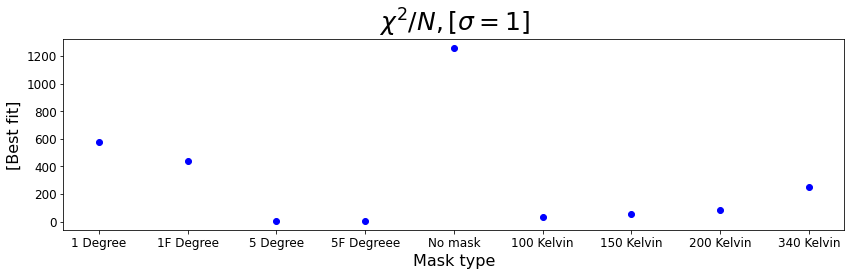

In [28]:
fig, axs = plt.subplots(figsize=(12, 4), nrows=1, ncols=1, sharey=True)
ax=axs
for i in range(len(chi_N_vals)):
    ax.plot(chi_x_label[i], chi_N_vals[i], 'bo', label='Original')
    # if i<1:
    #     ax.legend()
    
ax.set_title(r'$\chi^{2}/N, [\sigma=1]$')
ax.set_ylabel('[Best fit]')
ax.set_xlabel('Mask type')

fig.tight_layout()
# plt.savefig(pm.data_plot+'fitting/chi_square_'+str(f_pair[2][0])+'_'+str(f_pair[2][1])+'MHz_compare.pdf', bbox_inches='tight')


In [29]:
def mask_percentage(data):
    return np.round(100 * np.ma.sum(data.mask*1) / data.mask.size, 3)

### 1D plots

#### Degree mask or Kelvin mask

In [30]:
# Change here for the information

# Original
do = data_original
so = sims_original

# Kelvin
dk = data_kelvin
sk = sims_kelvin

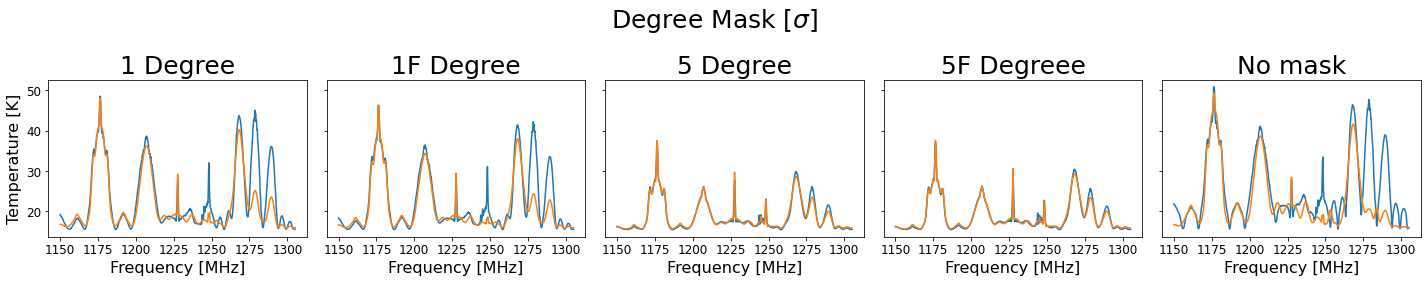

In [31]:
fig, axs = plt.subplots(figsize=(20, 4), ncols=5, sharey=True)

for i in range(len(mask_type_name)):
    fig.suptitle(r'Degree Mask [$\sigma$]')
    ax=axs[i]
    ax.set_title(mask_type_name[i])
    ax.plot(fslice, np.mean(do[i], axis=0))
    ax.plot(fslice, np.mean(so[i], axis=0))
    
    if i==0:
        ax.set_ylabel('Temperature [K]')
    ax.set_xlabel('Frequency [MHz]')
fig.tight_layout()

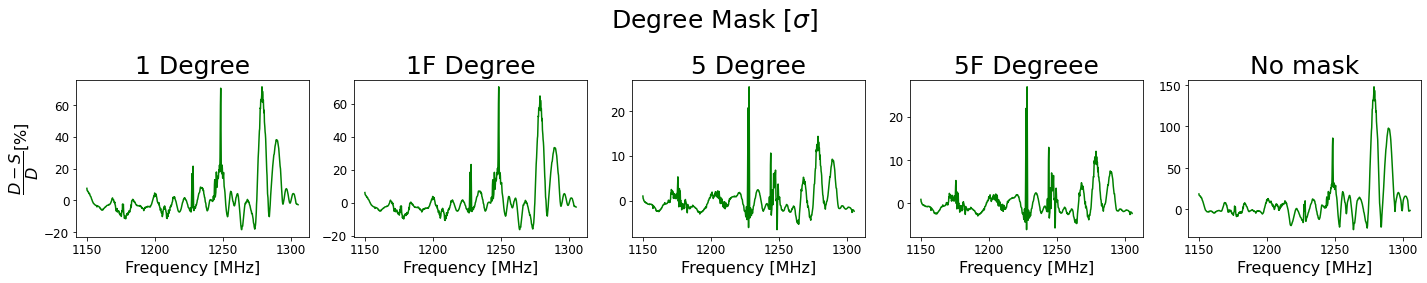

In [32]:
fig, axs = plt.subplots(figsize=(20, 4), ncols=5, sharey=False)

for i in range(len(mask_type_name)):
    fig.suptitle(r'Degree Mask [$\sigma$]')
    ax=axs[i]
    ax.set_title(mask_type_name[i])
    ax.plot(fslice, 100*np.mean((do[i] - so[i])/so[i], axis=0), color='green')
    
    if i==0:
        ax.set_ylabel(r'$\dfrac{D-S}{D} [\%]$')
    ax.set_xlabel('Frequency [MHz]')
fig.tight_layout()

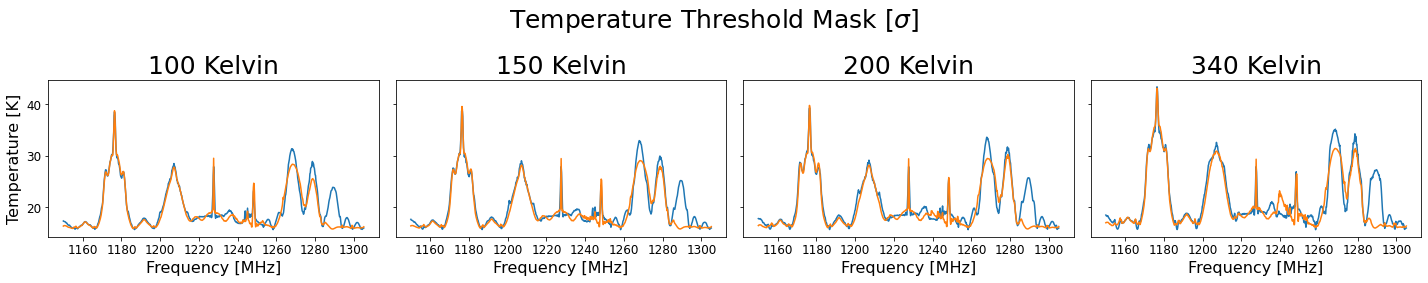

In [33]:
fig, axs = plt.subplots(figsize=(20, 4), ncols=4, sharey=True)

for i in range(len(k_vals)):
    fig.suptitle(r'Temperature Threshold Mask [$\sigma$]')
    ax=axs[i]
    ax.set_title(k_vals[i])
    ax.plot(fslice, np.mean(dk[i], axis=0))
    ax.plot(fslice, np.mean(sk[i], axis=0))
    
    if i==0:
        ax.set_ylabel('Temperature [K]')
    ax.set_xlabel('Frequency [MHz]')
fig.tight_layout()

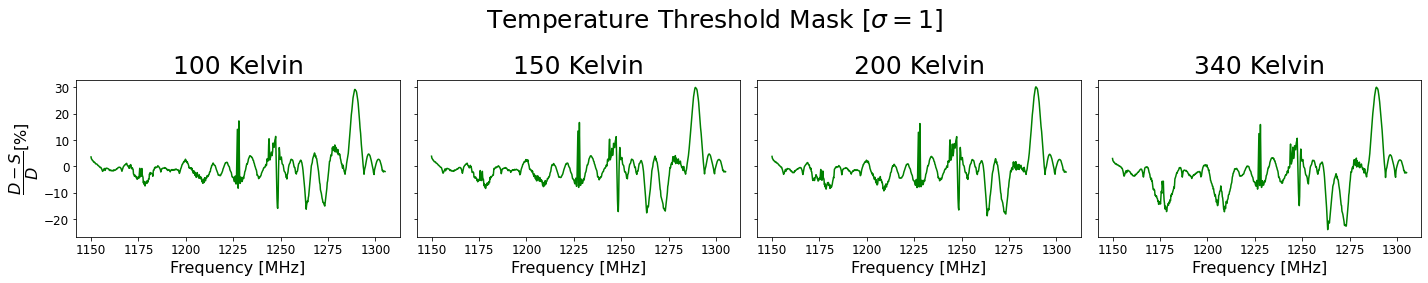

In [34]:
fig, axs = plt.subplots(figsize=(20, 4), ncols=4, sharey=True)

for i in range(len(k_vals)):
    fig.suptitle(r'Temperature Threshold Mask [$\sigma=1$]')
    ax=axs[i]
    ax.set_title(k_vals[i])
    ax.plot(fslice, 100*np.mean((dk[i] - sk[i])/dk[i], axis=0), color='g')
    
    if i==0:
        ax.set_ylabel(r'$\dfrac{D-S}{D} [\%]$')
    ax.set_xlabel('Frequency [MHz]')
fig.tight_layout()

#### Making the mask maps

Degree mask

In [1]:
deg = [1,1,5,5]
fil = [False, True, False, True]

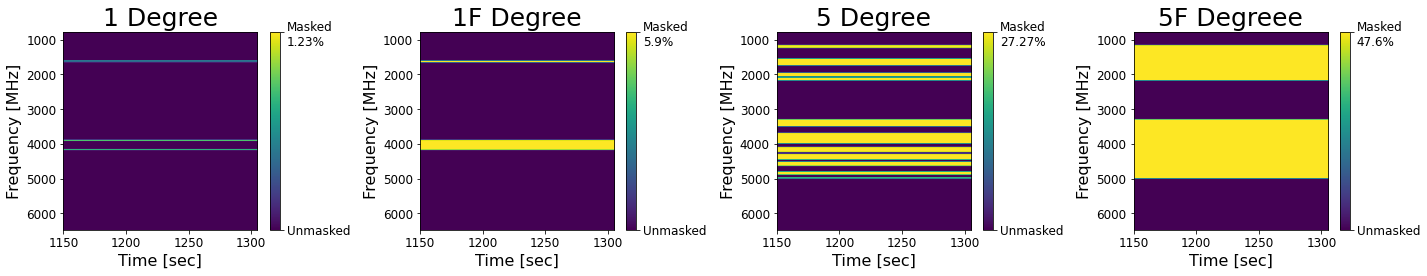

In [28]:
fig, axs = plt.subplots(figsize=(20, 4), nrows=1, ncols=4)
for i in range(4):
    ones = np.zeros(data.shape)
    ones[masking_idx(degree=deg[i], fill=fil[i])] = 1
    m_value = np.round(np.sum(ones) / np.size(ones) *100,2)
    ax = axs[i]

    cax = ax.imshow(ones, aspect='auto', extent=[fslice[0], fslice[-1], pm.nd_s0[-1], pm.nd_s0[0]])
    cbar = fig.colorbar(cax, ax=ax, ticks=[0, 1])
    cbar.ax.set_yticklabels(['Unmasked', 'Masked\n'+str(m_value)+'%'])  # vertically oriented colorbar

    ax.set_title(mask_type_name[i])
    ax.set_xlabel('Time [sec]')
    ax.set_ylabel('Frequency [MHz]')

fig.tight_layout()

Kelvin mask

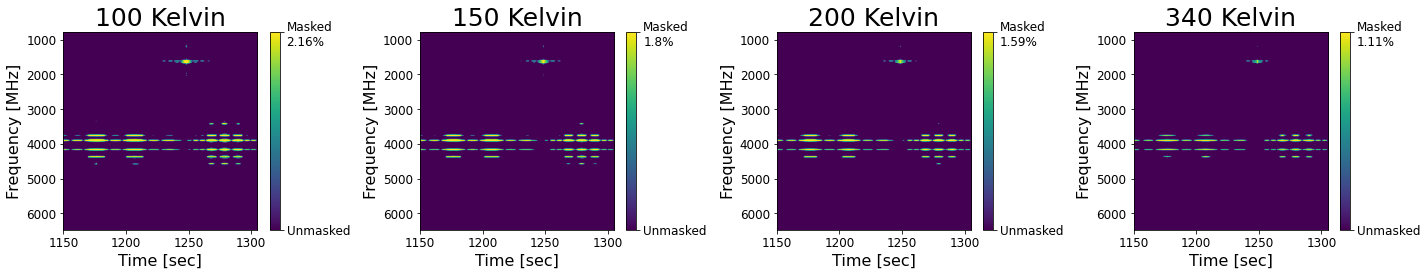

In [29]:
fig, axs = plt.subplots(figsize=(20, 4), nrows=1, ncols=4)
for i in range(len(k_temps)):

    dkm = data_kelvin[i].mask*1
    dkm_value = np.round(np.sum(dkm) / dkm.size * 100, 2)
    
    ax = axs[i]
    cax = ax.imshow(dkm, aspect='auto', extent=[fslice[0], fslice[-1], pm.nd_s0[-1], pm.nd_s0[0]])
    cbar = fig.colorbar(cax, ax=ax, ticks=[0, 1])
    cbar.ax.set_yticklabels(['Unmasked', 'Masked\n'+str(dkm_value)+'%']) # vertically oriented colorbar

    ax.set_title(str(k_temps[i])+' Kelvin')
    ax.set_xlabel('Time [sec]')
    ax.set_ylabel('Frequency [MHz]')

fig.tight_layout()

In [ ]:
# degree_type = ['1', '1_fill', '5', '5_fill', '1']
# mask_on = [True, True, True, True, False]
# timer_on = [False, False, False, False, False, True,  True]

# suf_list = ['_v2_new_version', '_v2_old_version', '_v3_increased_pg', '_v4_reduced_signal', '_v2_sig1', '_v2_avg20', '_v2_sig1_avg20']
# sat_cat_suffix_og = ['2', '2_old_version', '3', '4', '2', '2', '2']


# print ('Versions saved: ',suf_list)

# print ('Time average: ', timer_on)

# print ('Satellite catalog suffix: ',sat_cat_suffix_og)

# print ('Mask type:',mask_type)

# print ('Degree type: ',degree_type)

# print ('Mask versions:',mask_on)

In [ ]:
# # Dictionary for the different satellite catalogs
# # Each catalog looks contains Mask Type 

# satcat_version_data, satcat_version_sims = {}, {}

# for cat_i in range(len(sat_cat_suffix_og)):

#     cds, sts = [], []
#     for i in range(len(mask_type)):
#         a_values = df_a_list[cat_i].loc[df_a_list[cat_i].index == mask_type[i]].values[0]
#         sat_ex = satellite_excecute(alpha=a_values, degree=degree_type[i], sat_cat_suffix=sat_cat_suffix_og[cat_i], mask=mask_on[i], timer=timer_on[cat_i])
#         cds.append(sat_ex[0])
#         sts.append(sat_ex[1])
#         frange = sat_ex[2]
                                        
#     satcat_version_data.update({suf_list[cat_i]:cds})
#     satcat_version_sims.update({suf_list[cat_i]:sts})

In [ ]:
# key = 2
# fig, axs  = plt.subplots(figsize=(20,8), ncols=2, nrows=2)

# ax=axs[0,0]
# for si, satcat_type in enumerate(suf_list):
#     ax.set_title('Data response for '+mask_type[key])
#     ax.plot(fslice, np.mean(satcat_version_data[satcat_type][key], axis=0), color='k', label='Data')
#     ax.set_ylabel('Temperature [K]')
#     ax.set_xlabel('Frequency range [MHz]')
#     if si==0:
#         ax.legend()
    
# ax=axs[0,1] 
# fig.delaxes(ax)

# ax=axs[1,0]
# for si, satcat_type in enumerate(suf_list):
#     ax.set_title('Simulation response for '+mask_type[key])
#     ax.plot(fslice, np.mean(satcat_version_sims[satcat_type][key], axis=0), label='SatCat - '+suf_list[si])
#     handles, labels = ax.get_legend_handles_labels()
#     ax.set_ylabel('Temperature [K]')
#     ax.set_xlabel('Frequency range [MHz]')
    
# ax=axs[1,1]
# for si, satcat_type in enumerate(suf_list):
#     ax.set_title('Residual for '+mask_type[key])
#     yvals = np.mean(satcat_version_data[satcat_type][key], axis=0) - np.mean(satcat_version_sims[satcat_type][key], axis=0)
#     ax.plot(fslice, yvals, label=satcat_type)
#     ax.set_ylabel('Temperature [K]')
#     ax.set_xlabel('Frequency range [MHz]')
    

# fig.legend(handles, labels, loc='lower right', bbox_to_anchor=[0.8, 0.7])
# fig.tight_layout()
# # plt.savefig(pm.data_plot+'fitting/best_fit_'+mask_type[key]+'+_'+str(f_pair[2][0])+'_'+str(f_pair[2][1])+'MHz_compare.pdf', bbox_inches='tight')
# fig.show()

#### Frequency plots

In [ ]:
# f_val = 1200   # Frequency choice


# fig, axs = plt.subplots(figsize=(14, 10), nrows=5, ncols=1, sharex=False)

# for mi in range(len(mask_type)):
#     for si in suf_list:
#         yvals = tools.timeline(f_choice=f_val, f_list=fslice, waterfall=satcat_version_sims[si][mi])
        
#         if si in ['_v2_avg20', '_v2_sig1_avg20']:
#             xvals = tools.waterfall_avg_time(timer=pm.nd_s0, size=20, waterfall=None)
#         else:
#             xvals = pm.nd_s0
        
            
#         ax = axs[mi]
#         ax.set_title(mask_type[mi])
#         ax.plot(xvals, yvals, label='Satellite Cat: '+si)
        
#         # ax.set_xlim(3750, 4500)

#         if mi>3:
#             ax.set_xlabel('Time [sec]')
#         ax.set_ylabel('Temperature [K]')
        
#         if mi==1:
#             ax.legend(loc='upper left', bbox_to_anchor=(0.01, 1.02), ncol=2, fancybox=False, shadow=False)
        
    
# fig.tight_layout()

In [ ]:
# mi=4
# f_val_list = 1180+np.arange(40)# 1240, 1305]#[1176, 1191, 1227, 1268, 1278]

# fig, axs = plt.subplots(figsize=(15, 4*len(f_val_list)), nrows=len(f_val_list), ncols=1, sharex=False)

# for fi, f_val in enumerate(f_val_list):
#     ax=axs[fi]
#     for si in range(len(suf_list)):
        
#         if suf_list[si] in ['_v2_avg20', '_v2_sig1_avg20']:
#             xvals = tools.waterfall_avg_time(timer=pm.nd_s0, size=20, waterfall=None)
#         else:
#             xvals = pm.nd_s0
            
#         yvals = tools.timeline(f_choice=f_val, f_list=frange, waterfall=satcat_version_sims[suf_list[si]][mi])               
#         # PLOTTING    
#         ax.plot(xvals,(yvals), label='Satellite Cat: '+suf_list[si])
   
#     yvald = tools.timeline(f_choice=f_val, f_list=frange, waterfall=satcat_version_data[suf_list[0]][mi])
#     # PLOTTING
#     ax.plot(pm.nd_s0,(yvald), color='k', label='Data')

#     ax.set_title(mask_type[mi]+'- Frequency: '+str(f_val)+' MHz')
   
#     # X AND Y LIMITS
#     ax.set_xlim(3250, 5000)
#     ax.set_ylim(300, 350)   # Linear
#     # ax.set_ylim(1, 3)   # Logged
    
#     ax.set_xlabel('Time [sec]')
#     ax.set_ylabel('Temperature [K]')

# handles, labels = ax.get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower right', ncol=5, bbox_to_anchor=[0.99, 1])

# fig.tight_layout()
# # plt.savefig(pm.data_plot+'fitting/single_f_multi_1180_'+str(len(f_val_list))+'_satellite_t_'+str(pm.fs)+'_'+str(pm.fe)+'MHz_'+mask_type[mi]+'_.pdf', bbox_inches='tight')
# fig.show()

In [139]:
chi_N_kelvin

[33.024231175463484, 57.30848590323984, 85.49849531912886, 249.57585756728233]

#### Fitting to smaller time regions in the data

In [10]:
ts = [775, 2400, 5500]
te = [1000, 2600, 6200]

st_path = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/'
stf_name = 'full_no_mask_satellite_f_1000_1500MHz__1150_1350MHz_'+str(ts[0])+'_'+str(te[0])+'_sec_v2.p'

In [13]:
time_alpha = []
time_chi = []
time_chi_N = []
for times in range(3):
    st_path = '/users/bengelbrecht/hi_im/brandon/meerkat_gain_cali/1551055211/sat_2/'
    stf_name = 'full_no_mask_satellite_f_1000_1500MHz__1100_1350MHz_'+str(ts[times])+'_'+str(te[times])+'_sec_v2.p'
    
    dic_vals = pickle.load(open(st_path+stf_name, 'rb'))
    print ('Time: '+str(ts[times])+'-'+str(te[times])+' - '+str(dic_vals['chi2_value'])+' - '+str(dic_vals['chi2_div']))
    
    time_alpha.append(dic_vals['best-fit'])
    time_chi.append(dic_vals['chi2_value'])
    time_chi_N.append(dic_vals['chi2_div'])

Time: 775-1000 - 57068.549596660305 - 0.5534510308654529
Time: 2400-2600 - 158145.35604091513 - 1.7129572916923748
Time: 5500-6200 - 359342.8331355926 - 1.0898258643887864


### Chi Square testing

#### Function

In [58]:
##CHI SQAURE METHOD
def chisq_func2(a_param, frequency_slice=False, time_slice=False, t_mask=False, d_mask=False ,time_avg=False, damper=[None, None], sigma=False, verbose=False):
    
    """INITIALIZING THE SATELLITE FUNCTION"""
    sat = ss(file_name=fname,          
                 sats_only=None, 
                 data_loc=pm.data_save, 
                 sat_loc=pm.data_save,
                 survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
                 sat_info=pm.satellite_catalogue,
                 plots_loc=pm.data_plot,
                 sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
                 frequency_range=[pm.fs, pm.fe], 
                 constellations=pm.constellations_remain,
                 nearby_satellites=pm.nearby_constellations,
                 verbose=False)
    
    """EXCECUTING THE THE SATELLITE SIM FUNCTION"""
    sat.excecute(a_param=a_param, 
                 obs_time_start=time_slice[0], obs_time_end=time_slice[1], 
                 obs_frequency_start=frequency_slice[0], obs_frequency_end=frequency_slice[1], 
                 file_bias_choice=pm.bias, 
                 add_sub=[1, 1], 
                 band_lvl=[damper[0], damper[1]], 
                 bandsize=None,
                 verbose=False)

    """FREQUENCY SLICE"""
    frange_slice = sat.frequency_band[sat.frequency_idx[0]:sat.frequency_idx[1]]  
    
    """MASKING"""
    ## TEMPERATURE MASKING 
    if t_mask!=False and d_mask==False:
        print ('Temperature mask of '+str(t_mask)+' Kelvin')
        zero_arr = np.zeros(sat.calibration_data_slice.shape)
        mask_idx = np.where(sat.calibration_data_slice > t_mask)

        zero_arr[mask_idx]=1
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=zero_arr.T)    #SIMULATIONS
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=zero_arr.T)  #DATA

    ## DEGREE MASKING
    elif d_mask!=False and t_mask==False:
        print ("Area mask of "+str(d_mask)+" degrees")
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=sat.mask_nearby_satellites_slice)
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=sat.mask_nearby_satellites_slice)
    
    ## NO MASKING
    else:
        print ("No masking applied")
        simulation = np.ma.array(data=sat.simulation_TOD_slice.T, mask=None)
        data = np.ma.array(data=sat.calibration_data_slice.T, mask=None)
        
    """TIME AVERAGING"""
    if time_avg!=False:
        print ("Time averageing for every "+str(time_avg)+" seconds")
        #Averaging over time - MISSING TIMER PARAMETER
        data = tools.waterfall_avg_time(timer=pm.nd_s0, size=20, waterfall=data)
        simulation = tools.waterfall_avg_time(timer=pm.nd_s0, size=20, waterfall=simulation)
    
    """CHI SQAURE NUMERATOR"""
    chi_num = simulation - data  # WANT THIS VALUE

    """SIGMA CHOICE"""
    if sigma==True:
        sig=tools.radiometer_eq(data=data)  # Note this is sigma (expected noise level), it must be squared to give the radiometer equation
    else: 
        sig=1
    
    """CHI SQUARE VALUE"""
    chi_sq = np.ma.sum(chi_num**2 / sig**2)
      
    chi_sq_N = chi_sq /  np.ma.size(data)
    
    if verbose==True:
        print ("Chi numerator value: "+str(np.sum(chi_num)))
        print ("Chi Square value: "+str(chi_sq))
        print ("Chi Square N value: "+str(chi_sq_N))

    return data, simulation, chi_sq_N, frange_slice

In [55]:
pm.satellite_catalogue

'/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_2_bw.csv'

### Time steps

In [66]:
data_time, sim_time = [], []
for times in range(3):
    vals = chisq_func2(a_param=time_alpha[times], frequency_slice=[1100, 1350], time_slice=[ts[times], te[times]], 
                       damper=[None, 10*np.ones(len(pd.read_csv(pm.satellite_catalogue)))], verbose=False)
    data_time.append(vals[0])
    sim_time.append(vals[1])
    fslice = vals[3]

No masking applied
No masking applied
No masking applied


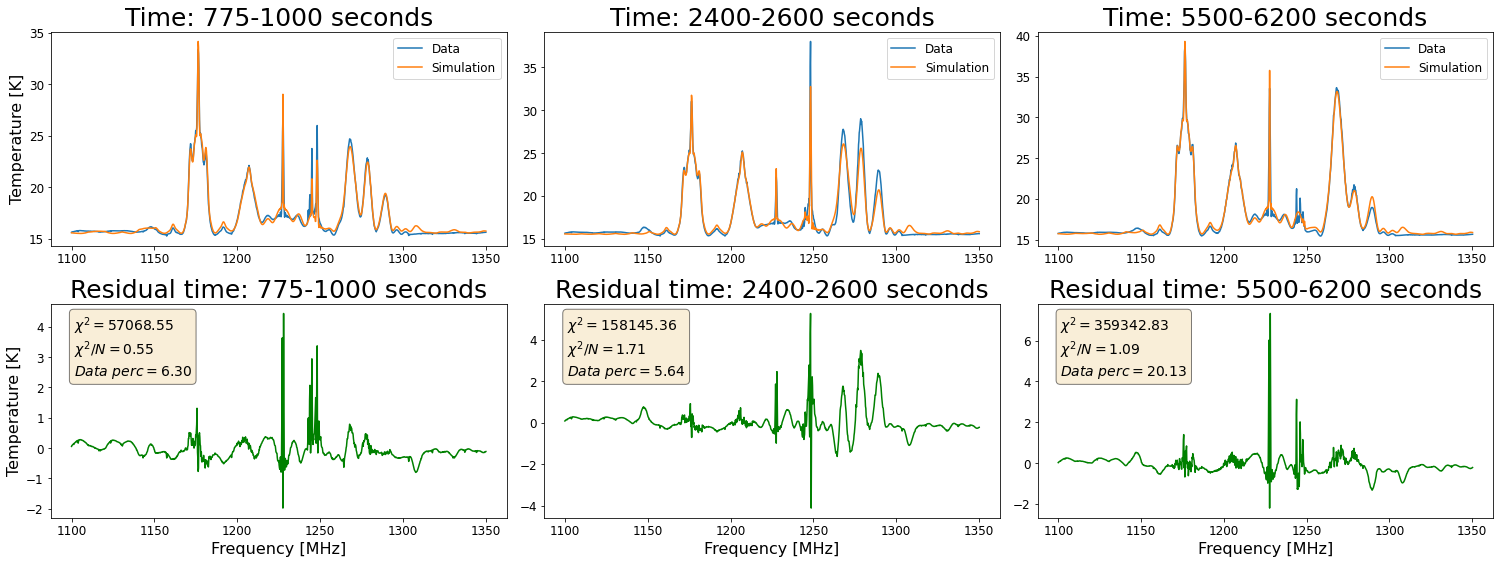

In [67]:
fig, axs = plt.subplots(figsize=(21, 8), ncols=3, nrows=2, sharey=False)

for k in range(2):
    for i in range(3):
        ax=axs[k, i]
        if k==0:
            ax.set_title('Time: '+str(ts[i])+'-'+str(te[i])+' seconds')
            ax.plot(fslice, np.ma.mean(data_time[i], axis=0), label='Data')
            ax.plot(fslice, np.ma.mean(sim_time[i], axis=0), label='Simulation')
            ax.legend()
            
        else:
            ax.set_title('Residual time: '+str(ts[i])+'-'+str(te[i])+' seconds')
            ax.plot(fslice, np.ma.mean(data_time[i] - sim_time[i], axis=0), color='green', label='Residual')
            
            textstr = '\n'.join((
                r'$\chi^2=%.2f$' % (np.round(time_chi[i], 2), ),
                r'$\chi^2/N=%.2f$' % (np.round(time_chi_N[i], 2), ),
                r'$Data\ perc =%.2f$' % (np.round(100*(data_time[i].size / data.size), 2), ),))


            props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

            # place a text box in upper left in axes coords
            ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=14,
                    verticalalignment='top', bbox=props)

        if k==1:
            ax.set_xlabel('Frequency [MHz]')
        if i==0:
            ax.set_ylabel('Temperature [K]')

        
fig.tight_layout()

#### Changing a signle alpha parameter for the 100 Kelvin masking threshold

In [74]:
test_alpha_100 = alpha_kelvin[0]
values = [0, 1, 2, 10, 25, 30, 100, 240]
best_test100 = []
for i in values:
    test_alpha_100[10] = 0.004*i
    print (test_alpha_100[10])
    best_test100.append(chisq_func2(a_param=test_alpha_100, t_mask=100, sigma=False))
    print ('\n')

0.0


NameError: name 'd_mask' is not defined

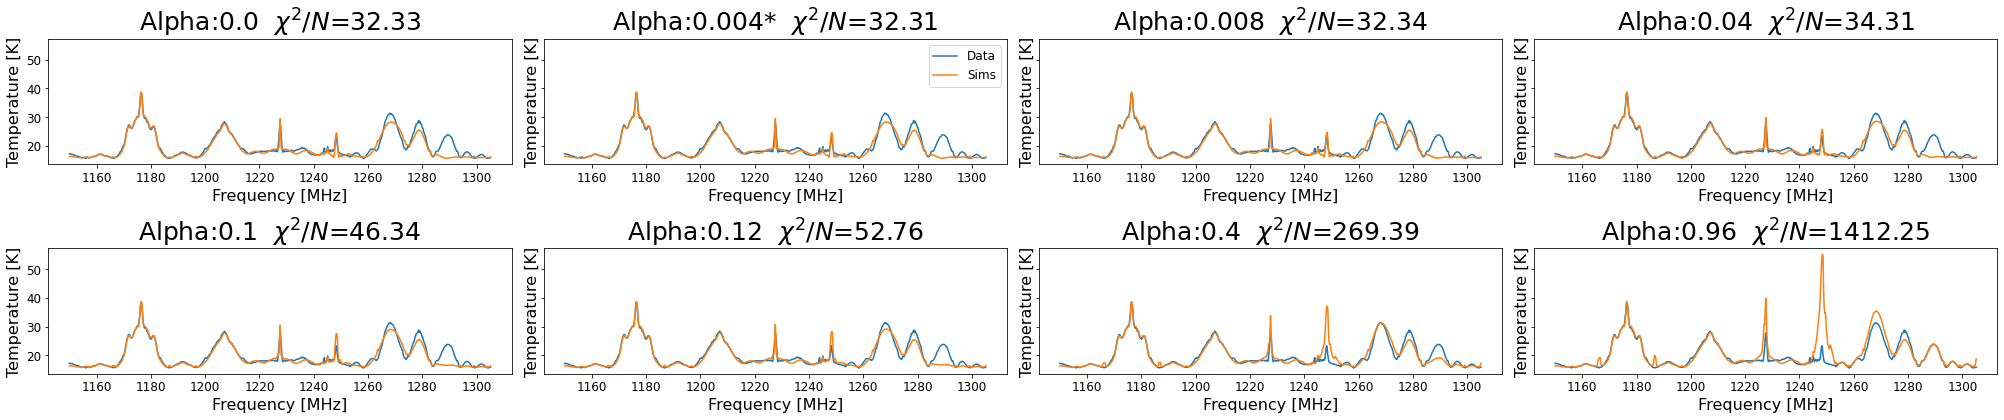

In [77]:
fig, axs = plt.subplots(figsize=(28, 6), nrows=2, ncols=4, sharey=True)
for pt in range(len(best_test100)):
    if pt<4:
        row = 0
        col = pt
    else: 
        row = 1
        col = pt-4
    
    ax = axs[row, col]
    ax.plot(fslice, np.ma.mean(best_test100[pt][0], axis=0), label='Data')
    ax.plot(fslice, np.ma.mean(best_test100[pt][1], axis=0), label='Sims')
    if pt == 1:
        ax.set_title(r'Alpha:'+str(0.004*values[pt])+'*  '+r'$\chi^2/N$='+str(np.round(best_test100[pt][2],2)))
        ax.legend()
    else:
        ax.set_title(r'Alpha:'+str(0.004*values[pt])+r'  $\chi^2/N$='+str(np.round(best_test100[pt][2],2)))
    
    ax.set_xlabel('Frequency [MHz]')
    ax.set_ylabel('Temperature [K]')
        

fig.tight_layout()
plt.show()

#### Looking at indiviudal constellation signals

In [219]:
alpha = alpha_degree[-1]   # No mask alpha case
degree = '1'
sat_cat_suffix = '2'
satsonly = None
mask=False 
k_mask=None 
timer=False 




sat_cat = '/users/bengelbrecht/PhD_Work/Satellite_Code/satellite_RFI-untangle/Notebooks/Satellite_Catalogue/table3B_satellite_v3-1_reduced_'+sat_cat_suffix+'.csv'

sat_test = ss(file_name=fname,          
             sats_only=satsonly, 
             data_loc=pm.data_save, 
             sat_loc=pm.data_save,
             survey_info=[pm.nd_s0, pm.nd_s0_coords, pm.frequency], 
             sat_info=sat_cat,
             plots_loc=pm.data_plot,
             sat_beam=pm.beam_model+'_beam_'+str(pm.fs)+'_'+str(pm.fe)+'MHz', 
             frequency_range=[pm.fs,pm.fe], 
             constellations=pm.constellations_remain,
             nearby_satellites=pm.data_save+'nearby_satellites/nearby_satellite_close_angle_'+str(degree)+'.p',
             verbose=False)


sat_test.excecute(a_param=alpha,
                 obs_time_start=pm.nd_s0[0], obs_time_end=pm.nd_s0[-1], 
                 obs_frequency_start=fs_slice, obs_frequency_end=fe_slice, 
                 file_bias_choice=pm.bias, 
                 add_sub=[1, 1], 
                 band_lvl=[None, None], 
                 bandsize=None,
                 verbose=True)


Number of signals inside choice frequency range:  21


In [220]:
sat_indi = sat_test.satellite_TOD_slice + sat_test.calibration_noise_slice
sat_indi_sum = np.ma.sum(sat_test.satellite_TOD_slice, axis=0) + sat_test.calibration_noise_slice

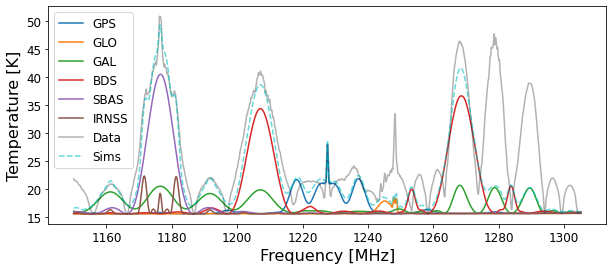

In [221]:
plt.figure(figsize=(10, 4))


for si, satname in enumerate(sat_test.cons):
    plt.plot(fslice, np.mean(sat_indi[si], axis=1), label=satname)

plt.plot(fslice, np.mean(sat_test.calibration_data_slice, axis=1), color='k', alpha=0.3, label='Data')
plt.plot(fslice, np.mean(sat_indi_sum, axis=1), '--c', alpha=0.6, label='Sims')


plt.xlabel('Frequency [MHz]')
plt.ylabel('Temperature [K]')
plt.legend()



In [ ]:
# MASKING SECTION   
if mask==True:
    # MASKING DEGREE STRIPS
    full_cds = np.ma.array(data=sat_test.calibration_data_slice.T, mask=sat_test.mask_nearby_satellites_slice)  #DATA
    full_sts = np.ma.array(data=sat_test.simulation_TOD_slice.T, mask=sat_test.mask_nearby_satellites_slice)    #SIMULATIONS

elif k_mask!=None:
    # MASKING THE THRESHOLD VALUES
    zero_arr = np.zeros(sat_test.calibration_data_slice.shape)
    mask_idx = np.where(sat_test.calibration_data_slice > k_mask)

    zero_arr[mask_idx]=1
    full_sts = np.ma.array(data=sat_test.simulation_TOD_slice.T, mask=zero_arr.T)    #SIMULATIONS
    full_cds = np.ma.array(data=sat_test.calibration_data_slice.T, mask=zero_arr.T)  #DATA

else:
    #NON-MASK
    full_cds = sat_test.calibration_data_slice.T   #DATA
    full_sts = sat_test.simulation_TOD_slice.T     #SIMULATION

plt.figure(figsize=(10, 4))

In [ ]:
for si, satname in enumerate(sat_test.cons):
    plt.plot(fslice, np.mean(sat_test.satellite_TOD_slice[si], axis=1), label=satname)
plt.legend()
